# MLOps Project – Credit Default Prediction

collaborators : 
Guillaume PATIENT
Talib BATOU
Cédric MANELLI


## Introduction

This project is part of an MLOps initiative conducted at Sorbonne University. We work in the context of retail banking, where personal loans represent a significant source of revenue but also carry the risk of borrower default. A default occurs when a borrower fails to meet their repayment obligations, leading to financial losses for the institution.

The objective of this project is to build a predictive model capable of estimating the probability of default for each client, based on their characteristics. Accurate predictions enable the bank to better manage risk, allocate capital efficiently, and maintain financial stability.

## MLOps Approach

This project follows an end-to-end MLOps methodology, covering the full machine learning lifecycle:

- Data preprocessing and feature engineering  
- Model development and comparison (e.g., logistic regression, decision trees, random forests)  
- Experiment tracking using MLflow  
- Model selection based on performance metrics  
- Deployment of the selected model through a web application (Streamlit or Flask)  
- Implementation of a CI/CD pipeline for automated deployment  

Each experiment is tracked using MLflow, with a clear structure:
- One experiment per model  
- Multiple runs corresponding to model iterations  

Version control is managed through Git from the beginning of the project to ensure collaboration, reproducibility, and traceability.

## Objectives

The main goals of this project are:

- Develop a robust and interpretable credit risk prediction model  
- Apply MLOps best practices in a real-world use case  
- Ensure reproducibility and scalability of the pipeline  
- Deploy a functional application accessible via a cloud platform  

## Project Organization

This notebook is structured according to the main stages of the MLOps pipeline:

1. Problem understanding and data exploration  
2. Data preprocessing  
3. Model training and evaluation  
4. Experiment tracking  
5. Model deployment preparation  

Each section reflects a key step toward building a production-ready machine learning system.

## 1) Data loading and data exploration

- Load the data by executing the cell below.

In [35]:
# import dataset from my google drive
import sys
import subprocess

try:
    import gdown
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown"])
    import gdown

# https://drive.google.com/file/d/1ynFzfRcInIGel_nCah3eD7IbGsrVlUbM/view?usp=sharing

# Google Drive file ID
file_id = "1ynFzfRcInIGel_nCah3eD7IbGsrVlUbM"

# Correct download URL format
url = f"https://drive.google.com/uc?id={file_id}"

# Local filename
filename = "loan_data.csv"

# Download the file
data = gdown.download(url=url, output=filename, quiet=False)

print("Download completed:", data)

Downloading...
From: https://drive.google.com/uc?id=1ynFzfRcInIGel_nCah3eD7IbGsrVlUbM
To: c:\Users\MANEL\Documents\data-analytics\MLOPS\projet\notebook\loan_data.csv
100%|██████████| 547k/547k [00:00<00:00, 6.59MB/s]

Download completed: loan_data.csv


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [37]:
# Chargement des données téléchargées à l'étape précédente
df = pd.read_csv("loan_data.csv")

print("--- Informations Générales ---")
display(df.info())
display(df.head())

--- Informations Générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


None

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [38]:
print("Valeurs manquantes :\n", df.isnull().sum())
print("\nNombre de doublons :", df.duplicated().sum())

Valeurs manquantes :
 customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Nombre de doublons : 0


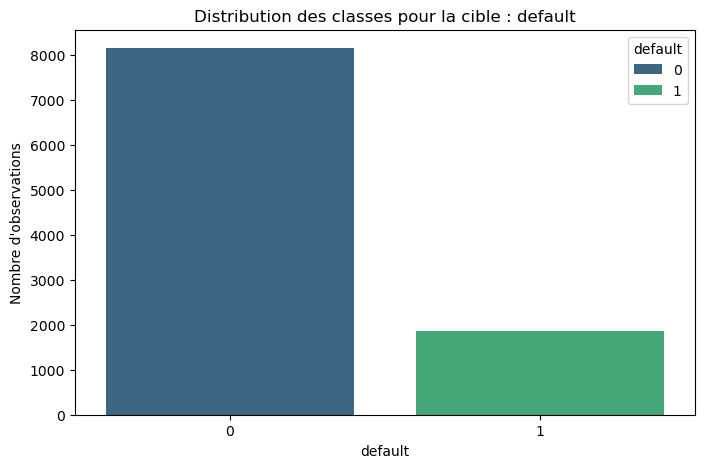

In [39]:
target_column = 'default' 

plt.figure(figsize=(8, 5))
sns.countplot(x=target_column, data=df, hue=target_column, palette='viridis')
plt.title(f'Distribution des classes pour la cible : {target_column}')
plt.ylabel('Nombre d\'observations')
plt.show()

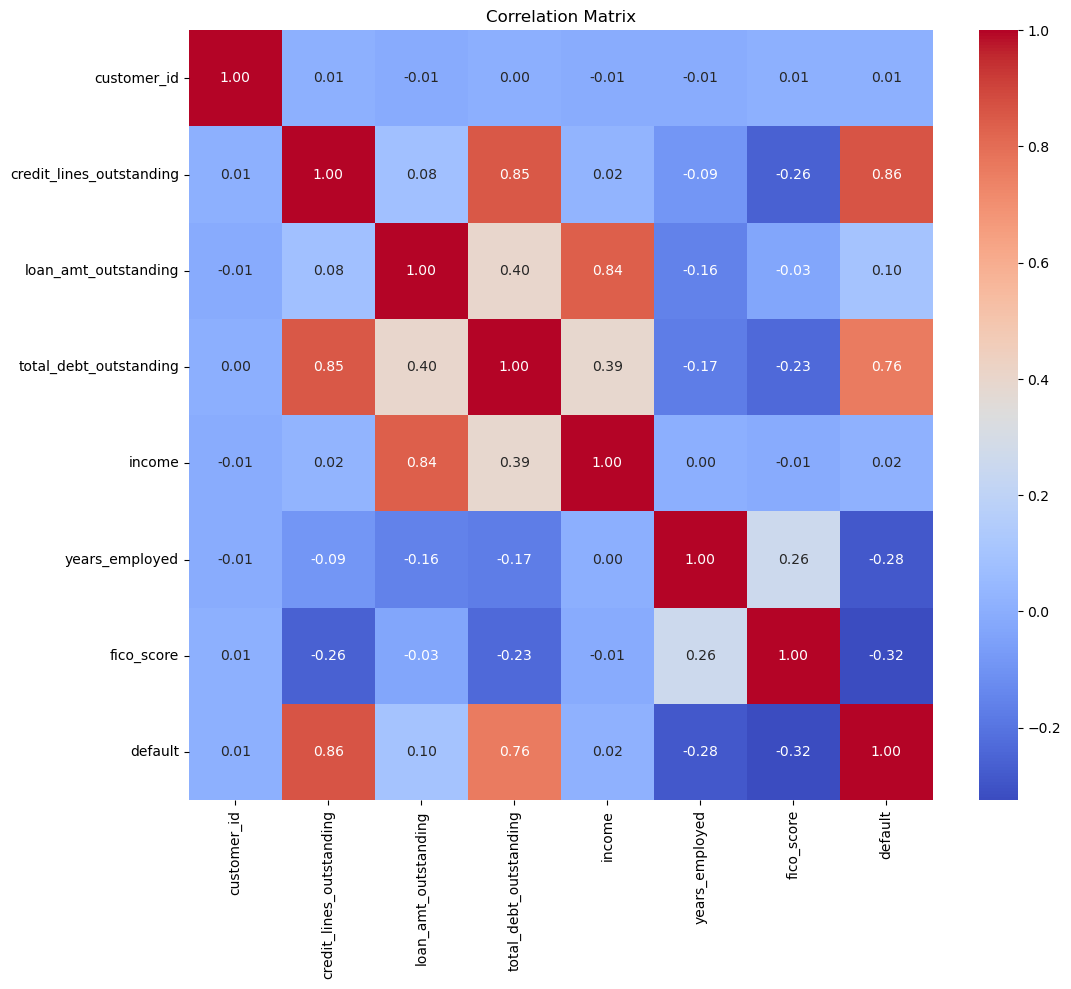

In [40]:
# checker la correlation entre les features et la cible
plt.figure(figsize=(12,10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [41]:
print("Proportion des classes :")
print(df[target_column].value_counts(normalize=True)*100)

Proportion des classes :
default
0    81.49
1    18.51
Name: proportion, dtype: float64


In [42]:
# Identification des colonnes textuelles/catégorielles
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Variables catégorielles identifiées : {list(cat_cols)}")

Variables catégorielles identifiées : []


In [43]:
# on supprime customer_id (pas de pouvoir prédictif)
df = df.drop(columns=["customer_id"])

In [44]:
# Séparer features et cible
X = df.drop(columns=["default"])
y = df["default"]

In [45]:
# Division train/test (80/20) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
print(f"Train : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")
print(f"\nDistribution avant SMOTE :")
print(y_train.value_counts())

Train : 8000 observations
Test  : 2000 observations

Distribution avant SMOTE :
default
0    6519
1    1481
Name: count, dtype: int64


In [47]:
print(f"\nDistribution du test :")
print(y_test.value_counts())


Distribution du test :
default
0    1630
1     370
Name: count, dtype: int64


In [48]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit uniquement sur le train

In [49]:
# SMOTE sur le jeu d'entraînement uniquement
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [50]:
print(f"\nDistribution après SMOTE :")
print(pd.Series(y_train_resampled).value_counts())
print(f"Nouvelles dimensions du train : {X_train_resampled.shape}")


Distribution après SMOTE :
default
1    6519
0    6519
Name: count, dtype: int64
Nouvelles dimensions du train : (13038, 6)


## 2) Model training and MLflow experiment tracking
In this section, we train and compare several classification models for credit default prediction.  
Each model is tracked in MLflow as a separate experiment, with runs corresponding to model configurations and training settings (with and without SMOTE).

In [51]:
import os
import joblib
import mlflow

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score
)

In [52]:
os.makedirs("models", exist_ok=True)

In [53]:
#Fonctions d'évaluation
def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "recall": recall_score(y_eval, y_pred),
        "f1_score": f1_score(y_eval, y_pred),
        "roc_auc": roc_auc_score(y_eval, y_proba)
    }

    return metrics

In [54]:
#Fonction MLFlow
from xml.parsers.expat import model

from sklearn.metrics import confusion_matrix


def run_experiment(experiment_name, run_name, model, params, use_smote=False):
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name=run_name):
        
        # Choix des données d'entraînement
        if use_smote:
            X_train_used = X_train_resampled
            y_train_used = y_train_resampled
        else:
            X_train_used = X_train_scaled
            y_train_used = y_train

        # Entraînement
        model.fit(X_train_used, y_train_used)

        # Évaluation sur le jeu de test
        train_metrics = evaluate_model(model, X_train_used, y_train_used)
        test_metrics  = evaluate_model(model, X_test_scaled, y_test)
        # Log paramètres
        all_params = params.copy()
        all_params["use_smote"] = use_smote
        mlflow.log_params(all_params)

        # Log métriques
        train_metrics_prefixed = {f"train_{k}": v for k, v in train_metrics.items()}
        test_metrics_prefixed  = {f"test_{k}": v for k, v in test_metrics.items()}
        
        mlflow.log_metrics(train_metrics_prefixed)
        mlflow.log_metrics(test_metrics_prefixed)

        # Sauvegarde locale
        model_path = f"models/{run_name}.joblib"
        joblib.dump(model, model_path)

        # Sauvegarde modèle dans MLflow
        mlflow.sklearn.log_model(model, artifact_path="model")
        mlflow.log_artifact(model_path)

        print(f"Experiment: {experiment_name}")
        print(f"Run: {run_name}")
        print(f"SMOTE: {use_smote}")
        print(f"train metrics:")
        print(train_metrics)
        print(f"test metrics:")
        print(test_metrics)
        print("-" * 60)
        y_pred = model.predict(X_test_scaled)
        print(confusion_matrix(y_test, y_pred))

        return {
            "experiment": experiment_name,
            "run_name": run_name,
            "use_smote": use_smote,
            **test_metrics
        }

In [55]:
#Logistics Regression
results = []
max_iter = 200
results.append(
    run_experiment(
        experiment_name="Logistic_Regression",
        run_name="logreg_baseline_no_smote",
        model=LogisticRegression(max_iter=max_iter, random_state=42),
        params={
            "model_type": "LogisticRegression",
            "max_iter": max_iter,
            "random_state": 42
        },
        use_smote=False
    )
)
results.append( 
run_experiment(
    experiment_name="Logistic_Regression",
    run_name="logreg_balanced",
    model=LogisticRegression(class_weight="balanced", max_iter=max_iter, random_state=42),
    params={
        "model_type": "LogisticRegression",
        "class_weight": "balanced",
        "max_iter": max_iter
    },
    use_smote=False
)
)
results.append(
    run_experiment(
        experiment_name="Logistic_Regression",
        run_name="logreg_smote",
        model=LogisticRegression(max_iter=max_iter, random_state=42),
        params={
            "model_type": "LogisticRegression",
            "max_iter": max_iter,
            "random_state": 42
        },
        use_smote=True
    )
)

2026/04/04 17:09:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:09:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 17:09:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:09:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Experiment: Logistic_Regression
Run: logreg_baseline_no_smote
SMOTE: False
train metrics:
{'recall': 0.9918973666441594, 'f1_score': 0.9949204199119539, 'roc_auc': np.float64(0.9999867421246926)}
test metrics:
{'recall': 0.9945945945945946, 'f1_score': 0.997289972899729, 'roc_auc': np.float64(0.9999883933012768)}
------------------------------------------------------------
[[1630    0]
 [   2  368]]


2026/04/04 17:09:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:09:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment: Logistic_Regression
Run: logreg_balanced
SMOTE: False
train metrics:
{'recall': 1.0, 'f1_score': 0.9840531561461794, 'roc_auc': np.float64(0.9999872600104468)}
test metrics:
{'recall': 1.0, 'f1_score': 0.9879839786381842, 'roc_auc': np.float64(0.9999883933012768)}
------------------------------------------------------------
[[1621    9]
 [   0  370]]
Experiment: Logistic_Regression
Run: logreg_smote
SMOTE: True
train metrics:
{'recall': 1.0, 'f1_score': 0.9973227262296336, 'roc_auc': np.float64(0.9999952232328027)}
test metrics:
{'recall': 1.0, 'f1_score': 0.9919571045576407, 'roc_auc': np.float64(0.9999900514010943)}
------------------------------------------------------------
[[1624    6]
 [   0  370]]


In [56]:
#Decision tree
results.append(
    run_experiment(
        experiment_name="Decision_Tree",
        run_name="dt_baseline_no_smote",
        model=DecisionTreeClassifier(random_state=42),
        params={
            "model_type": "DecisionTreeClassifier",
            "random_state": 42
        },
        use_smote=False
    )
)
results.append( 
run_experiment(
    experiment_name="Decision_Tree",
    run_name="decision_tree_balanced",
    model=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    params={
        "model_type": "DecisionTreeClassifier",
        "class_weight": "balanced"
    },
    use_smote=False
)
)

results.append(
    run_experiment(
        experiment_name="Decision_Tree",
        run_name="decision_tree_smote",
        model=DecisionTreeClassifier(random_state=42),
        params={
            "model_type": "DecisionTreeClassifier",
            "random_state": 42
        },
        use_smote=True
    )
)

2026/04/04 17:09:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:09:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 17:09:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:09:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Experiment: Decision_Tree
Run: dt_baseline_no_smote
SMOTE: False
train metrics:
{'recall': 1.0, 'f1_score': 1.0, 'roc_auc': np.float64(1.0)}
test metrics:
{'recall': 0.9864864864864865, 'f1_score': 0.9864864864864865, 'roc_auc': np.float64(0.9917095009119549)}
------------------------------------------------------------
[[1625    5]
 [   5  365]]


2026/04/04 17:09:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:09:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment: Decision_Tree
Run: decision_tree_balanced
SMOTE: False
train metrics:
{'recall': 1.0, 'f1_score': 1.0, 'roc_auc': np.float64(1.0)}
test metrics:
{'recall': 0.9837837837837838, 'f1_score': 0.986449864498645, 'roc_auc': np.float64(0.9906648980268613)}
------------------------------------------------------------
[[1626    4]
 [   6  364]]
Experiment: Decision_Tree
Run: decision_tree_smote
SMOTE: True
train metrics:
{'recall': 1.0, 'f1_score': 1.0, 'roc_auc': np.float64(1.0)}
test metrics:
{'recall': 0.9837837837837838, 'f1_score': 0.9851150202976996, 'roc_auc': np.float64(0.9903581495606036)}
------------------------------------------------------------
[[1625    5]
 [   6  364]]


In [57]:
#Random Forest
results.append(
    run_experiment(
        experiment_name="Random_Forest",
        run_name="rf_100_no_smote",
        model=RandomForestClassifier(n_estimators=100, random_state=42),
        params={
            "model_type": "RandomForestClassifier",
            "n_estimators": 100,
            "random_state": 42
        },
        use_smote=False
    )
)
results.append(
run_experiment(
    experiment_name="Random_Forest",
    run_name="random_forest_balanced",
    model=RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42),
    params={
        "model_type": "RandomForestClassifier",
        "class_weight": "balanced",
        "n_estimators": 100
    },
    use_smote=False
)
)

results.append(
    run_experiment(
        experiment_name="Random_Forest",
        run_name="random_forest_smote",
        model=RandomForestClassifier(n_estimators=100, random_state=42),
        params={
            "model_type": "RandomForestClassifier",
            "n_estimators": 100,
            "random_state": 42
        },
        use_smote=True
    )
)

2026/04/04 17:10:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:10:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment: Random_Forest
Run: rf_100_no_smote
SMOTE: False
train metrics:
{'recall': 1.0, 'f1_score': 1.0, 'roc_auc': np.float64(1.0)}
test metrics:
{'recall': 0.9864864864864865, 'f1_score': 0.989159891598916, 'roc_auc': np.float64(0.9998607196153209)}
------------------------------------------------------------
[[1627    3]
 [   5  365]]


2026/04/04 17:10:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:10:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment: Random_Forest
Run: random_forest_balanced
SMOTE: False
train metrics:
{'recall': 1.0, 'f1_score': 1.0, 'roc_auc': np.float64(1.0)}
test metrics:
{'recall': 0.9837837837837838, 'f1_score': 0.986449864498645, 'roc_auc': np.float64(0.9998648648648648)}
------------------------------------------------------------
[[1626    4]
 [   6  364]]


2026/04/04 17:10:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 17:10:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment: Random_Forest
Run: random_forest_smote
SMOTE: True
train metrics:
{'recall': 1.0, 'f1_score': 1.0, 'roc_auc': np.float64(1.0)}
test metrics:
{'recall': 0.9891891891891892, 'f1_score': 0.9878542510121457, 'roc_auc': np.float64(0.9998739844138617)}
------------------------------------------------------------
[[1625    5]
 [   4  366]]


In [58]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["recall", "f1_score", "roc_auc"], ascending=False)
results_df

,experiment,run_name,use_smote,recall,f1_score,roc_auc
2,Logistic_Regression,logreg_smote,True,1.000000,0.991957,0.999990
1,Logistic_Regression,logreg_balanced,False,1.000000,0.987984,0.999988
0,Logistic_Regression,logreg_baseline_no_smote,False,0.994595,0.997290,0.999988
8,Random_Forest,random_forest_smote,True,0.989189,0.987854,0.999874
6,Random_Forest,rf_100_no_smote,False,0.986486,0.989160,0.999861
3,Decision_Tree,dt_baseline_no_smote,False,0.986486,0.986486,0.991710
7,Random_Forest,random_forest_balanced,False,0.983784,0.986450,0.999865
4,Decision_Tree,decision_tree_balanced,False,0.983784,0.986450,0.990665
5,Decision_Tree,decision_tree_smote,True,0.983784,0.985115,0.990358


In [62]:
best_run = results_df.iloc[0]
best_run

experiment    Logistic_Regression
run_name             logreg_smote
use_smote                    True
recall                        1.0
f1_score                 0.991957
roc_auc                   0.99999
Name: 2, dtype: object

In [64]:
import joblib
from sklearn.pipeline import Pipeline

# Charger le meilleur modèle déjà entraîné
best_model_path = f"models/{best_run['run_name']}.joblib"
best_model = joblib.load(best_model_path)

# Reconstruire le pipeline avec le scaler utilisé avant l'entraînement
pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_model)
])

# Sauvegarder le pipeline final
joblib.dump(pipeline, "models/best_model.joblib")

['models/best_model.joblib']